In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb import sources

In [2]:
data = np.loadtxt("../codes/maps/normalised_dndz_cosmos.txt")

In [3]:
bias_blue  = lambda z: 0.8 + 1.2*z
bias_green = lambda z: np.maximum(1.6*z**2, 1.0)
bias_red   = lambda z: np.maximum(2.0*z**1.5, 1.0)

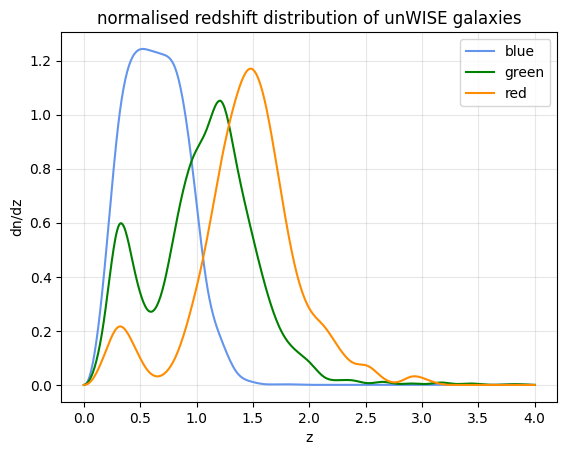

In [15]:
z = data[:, 0]
dndz_blue = data[:, 1]
dndz_green = data[:, 2]
dndz_red = data[:, 3]

# # Integrate each with the trapezoid rule, then divide
# dndz_blue /= np.trapezoid(dndz_blue, z)
# dndz_green /= np.trapezoid(dndz_green, z)
# dndz_red /= np.trapezoid(dndz_red, z)

plt.plot(z, dndz_blue, label="blue", linestyle="-", color="cornflowerblue")
plt.plot(z, dndz_green, label="green", linestyle="-", color="green")
plt.plot(z, dndz_red, label="red", linestyle="-", color="darkorange")
plt.xlabel("z")
plt.ylabel("dn/dz")
plt.title("normalised redshift distribution of unWISE galaxies")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

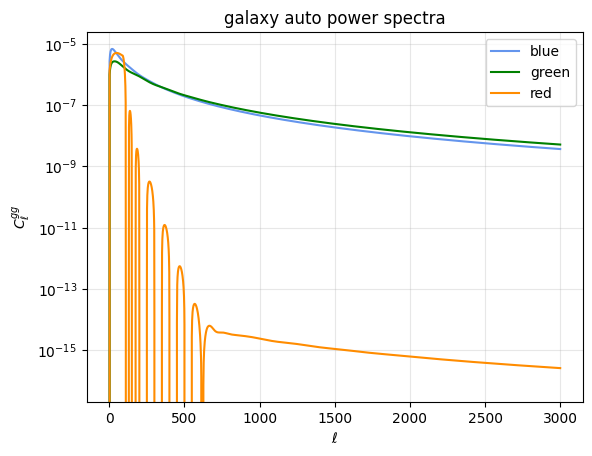

In [ ]:
# b_blue_fid = 1.56
# b_green_fid = 2.23
# b_red_fid = 3.29

# sigma_b_blue = 0.0276
# sigma_b_green = 0.0352
# sigma_b_red = 0.0352

# bias_blue = b_blue_fid * np.ones_like(z)
# bias_green = b_green_fid * np.ones_like(z)
# bias_red = b_red_fid * np.ones_like(z)

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.0224, omch2=0.120, mnu=0.06, tau=0.054)
pars.InitPower.set_params(As=2.1e-9, ns=0.965)

lmax = 3000
pars.set_for_lmax(lmax)

w_blue = sources.SplinedSourceWindow(source_type="counts", dlog10Ndm=0)
w_green = sources.SplinedSourceWindow(source_type="counts", dlog10Ndm=0)
w_red = sources.SplinedSourceWindow(source_type="counts", dlog10Ndm=0)

w_blue.set_table(z, dndz_blue, bias_z=bias_blue(z))
w_green.set_table(z, dndz_green, bias_z=bias_green(z))
w_red.set_table(z, dndz_red, bias_z=bias_red(z))

pars.SourceWindows = [w_blue, w_green, w_red]

pars.SourceTerms.counts_density = True
pars.SourceTerms.counts_redshift = False ###
pars.SourceTerms.counts_lensing = False ###
pars.SourceTerms.counts_velocity = False ###
pars.SourceTerms.counts_radial = False
pars.SourceTerms.counts_timedelay = False
pars.SourceTerms.counts_ISW = False
pars.SourceTerms.counts_potential = False

pars.SourceTerms.limber_windows = True

results = camb.get_results(pars)

cls = results.get_source_cls_dict(raw_cl=True)

cl_blue  = cls["W1xW1"][:lmax+1]
cl_green = cls["W2xW2"][:lmax+1]
cl_red   = cls["W3xW3"][:lmax+1]

ells = np.arange(lmax + 1)

plt.plot(ells, cl_blue, label="blue", color="cornflowerblue")
plt.plot(ells, cl_green, label="green", color="green")
plt.plot(ells, cl_red, label="red", color="darkorange")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{gg}$")
plt.yscale("log")
plt.title("galaxy auto power spectra")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# data_blue = np.array([
#     [0.12887893356643332, 0.20139860139860155],
#     [0.1889272836538458, 0.40000000000000013],
#     [0.23727737106643332, 0.6013986013986015],
#     [0.2856069711538459, 0.8],
#     [0.34565532124125853, 0.9986013986013986],
#     [0.4408804086538459, 1.2],
#     [0.5351221044580418, 1.2671328671328672],
#     [0.6400991586538459, 1.2],
#     [0.8085459462412586, 0.9986013986013986],
#     [0.9418569711538459, 0.8],
#     [1.0517304960664329, 0.6013986013986015],
#     [1.1557241586538458, 0.40000000000000013],
#     [1.2597383085664333, 0.20139860139860155],
#     [1.6274243334790208, 0.002797202797203191],
#     [2.0024243334790213, 0.002797202797203191],
#     [2.3251406796328666, 0.06433566433566451],
#     [2.740705583479021, 0.002797202797203191],
#     [3.2035962084790213, 0.002797202797203191]
# ])

# z_red = data_blue[:, 0]
# dndz_red = data_blue[:, 1]

# data_green = np.array([
#     [0.010236833479020713, 0.002797202797203191],
#     [0.18161330856643343, 0.20139860139860155],
#     [0.2533804086538459, 0.40000000000000013],
#     [0.3539731752622375, 0.5342657342657344],
#     [0.4936147836538459, 0.40000000000000013],
#     [0.6565299934440557, 0.24335664335664364],
#     [0.7865835336538459, 0.40000000000000013],
#     [0.8818086210664334, 0.6013986013986015],
#     [0.9711538461538459, 0.8],
#     [1.0068427666083917, 0.8727272727272728],
#     [1.1015146962412588, 0.9986013986013986],
#     [1.1897331184440554, 1.0433566433566435],
#     [1.2772959462412583, 0.9986013986013986],
#     [1.3988882211538458, 0.8],
#     [1.4970429960664333, 0.6013986013986015],
#     [1.6068960336538458, 0.40000000000000013],
#     [1.7870820585664333, 0.20139860139860155],
#     [2.003223339160839, 0.1118881118881121],
#     [2.278245192307692, 0.061538461538461764],
#     [2.705569820804196, 0.005594405594405716],
#     [2.9340854458041954, 0.005594405594405716],
#     [3.0864701704545445, 0.011188811188811654],
#     [3.297346208479021, 0.002797202797203191],
#     [3.561018083479021, 0.002797202797203191],
#     [3.848127458479021, 0.002797202797203191],
#     [3.994611833479021, 0.002797202797203191]
# ])

# z_green = data_green[:, 0]
# dndz_green = data_green[:, 1]

# data_red = np.array([
#     [0.010236833479020713, 0.002797202797203191],
#     [0.16909555288461497, 0.09230769230769242],
#     [0.310560533216783, 0.20699300699300704],
#     [0.4101084462412584, 0.19860139860139858],
#     [0.5384410511363636, 0.12027972027972034],
#     [0.6786972792832165, 0.06993006993007023],
#     [0.8081771743881115, 0.14825174825174847],
#     [0.8495410839160836, 0.19580419580419606],
#     [0.9383741258741257, 0.32447552447552463],
#     [0.9976849322552445, 0.42237762237762255],
#     [1.0806790865384612, 0.5538461538461539],
#     [1.1635298295454541, 0.6657342657342658],
#     [1.2520965362762233, 0.7580419580419581],
#     [1.322839270104895, 0.8167832167832169],
#     [1.4521757539335662, 0.8755244755244757],
#     [1.633611505681818, 0.8475524475524476],
#     [1.7908517263986012, 0.7160839160839162],
#     [1.8605905812937058, 0.6377622377622378],
#     [1.947661713286713, 0.525874125874126],
#     [2.0056818181818183, 0.4475524475524477],
#     [2.087016499125874, 0.35244755244755255],
#     [2.16835118006993, 0.2573426573426576],
#     [2.2264942089160837, 0.19580419580419606],
#     [2.313852163461538, 0.1230769230769233],
#     [2.418829217657343, 0.05594405594405605],
#     [2.5298500327797195, 0.013986013986014179],
#     [2.664533708479021, 0.002797202797203191],
#     [2.8461743334790204, 0.002797202797203191],
#     [3.0981684331293713, 0.008391608391608685],
#     [3.2623743444055946, 0.027972027972028135],
#     [3.4031222683566433, 0.04475524475524484],
#     [3.5789649803321675, 0.0531468531468533],
#     [3.719508031031469, 0.04195804195804209],
#     [3.860010107080419, 0.025174825174825388],
#     [3.994611833479021, 0.002797202797203191]
# ])

# z_red = data_red[:, 0]
# dndz_red = data_red[:, 1]

# z = np.arange(0.0, 3.0, 0.008)